# Deconvolve the replicating timing for the 10k bin curves using the Haar wavelet for a step-wise result

April 30, 2024

Compute the replicating timing from the deconvolved MNase-seq 10k windows for each gene.

**Goal:** Deconvolve the replication timing such that the result is a step-wise function
from G1 of copy number 1, S-phase (transition from 1 to 2 step-wise), and G2M as copy number 2.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()
mnase_analysis_rep1.compute_replication_timing()


1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:34.341


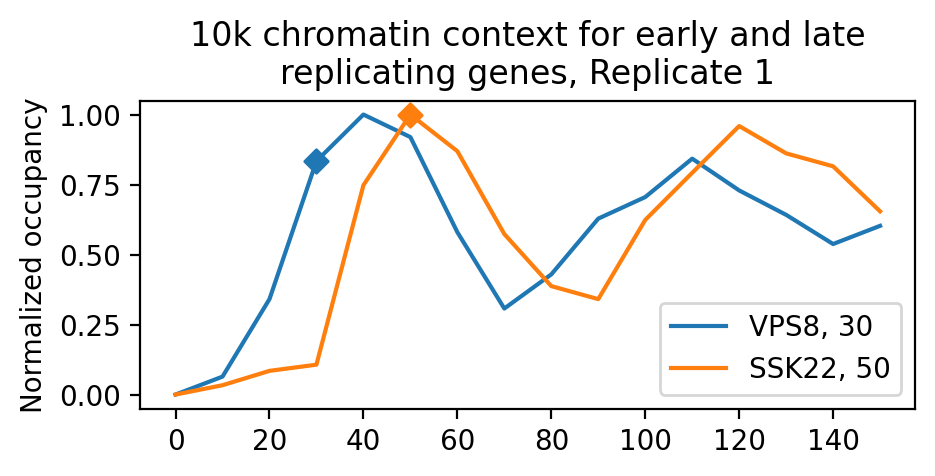

In [4]:
mnase_analysis_rep1.plot_normalized_bin_curves(['VPS8', 'SSK22'])

In [399]:
from src.sgd import get_orfname

orfname = get_orfname('CLN1')
#g = mnase_analysis_rep1.normalized_bin_curves.loc[orfname].values.reshape((-1, 1))
g = mnase_analysis_rep1.normalized_bin_curves.iloc[0:100].values.T

g = g + 1.
g.shape

(16, 100)

In [407]:
from src.geneset import get_deconvolved_geneset

geneset = get_deconvolved_geneset()

chr_genes = geneset[geneset.chr == 10]

chr_curves = mnase_analysis_rep1.normalized_bin_curves.join(chr_genes[[]], how='inner')
g = chr_curves.values.T

g = g + 1.

In [408]:
from src.dynamic_config_alpha import create_dynamic_alpha_config
from src.replication_deconvolution_solver import ReplicationChromatinDeconvolveSolver

In [707]:
config = create_dynamic_alpha_config(replicate=1, alpha=28)
solver = ReplicationChromatinDeconvolveSolver(config, g)
solver.define_deconvolution_problem()
_ = solver.solve(gamma_value=0.01, verbose=False)

In [708]:
f = solver.f.copy()

In [709]:
f_max = f.max(axis=0).reshape((1, -1))
f_min = f.min(axis=0).reshape((1, -1))
f_delta = f_max - f_min

f_norm = (f - f_min) / f_delta

In [710]:
t_indices = config.get_Hpositions_for_branch('t')
b_indices = config.get_Hpositions_for_branch('b')

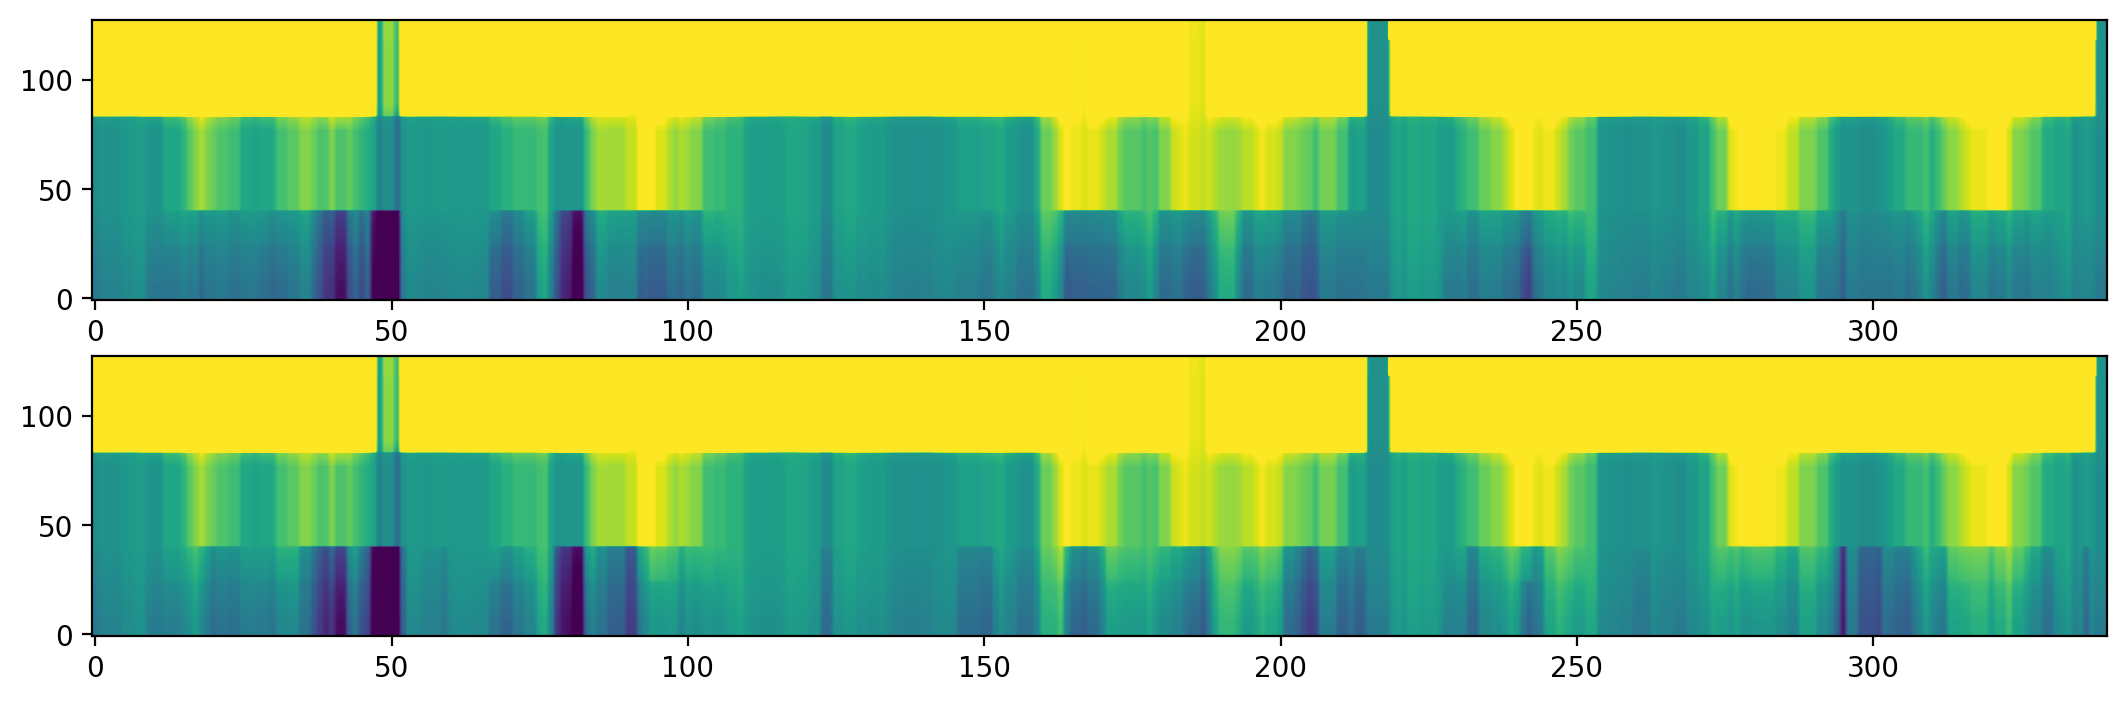

In [711]:
plt.figure(figsize=(13, 4))

plt.subplot(2, 1, 1)
plt.imshow(f[t_indices], aspect='auto', origin='lower', vmax=2., vmin=0.1)

plt.subplot(2, 1, 2)
plt.imshow(f[b_indices], aspect='auto', origin='lower', vmax=2., vmin=0.1)

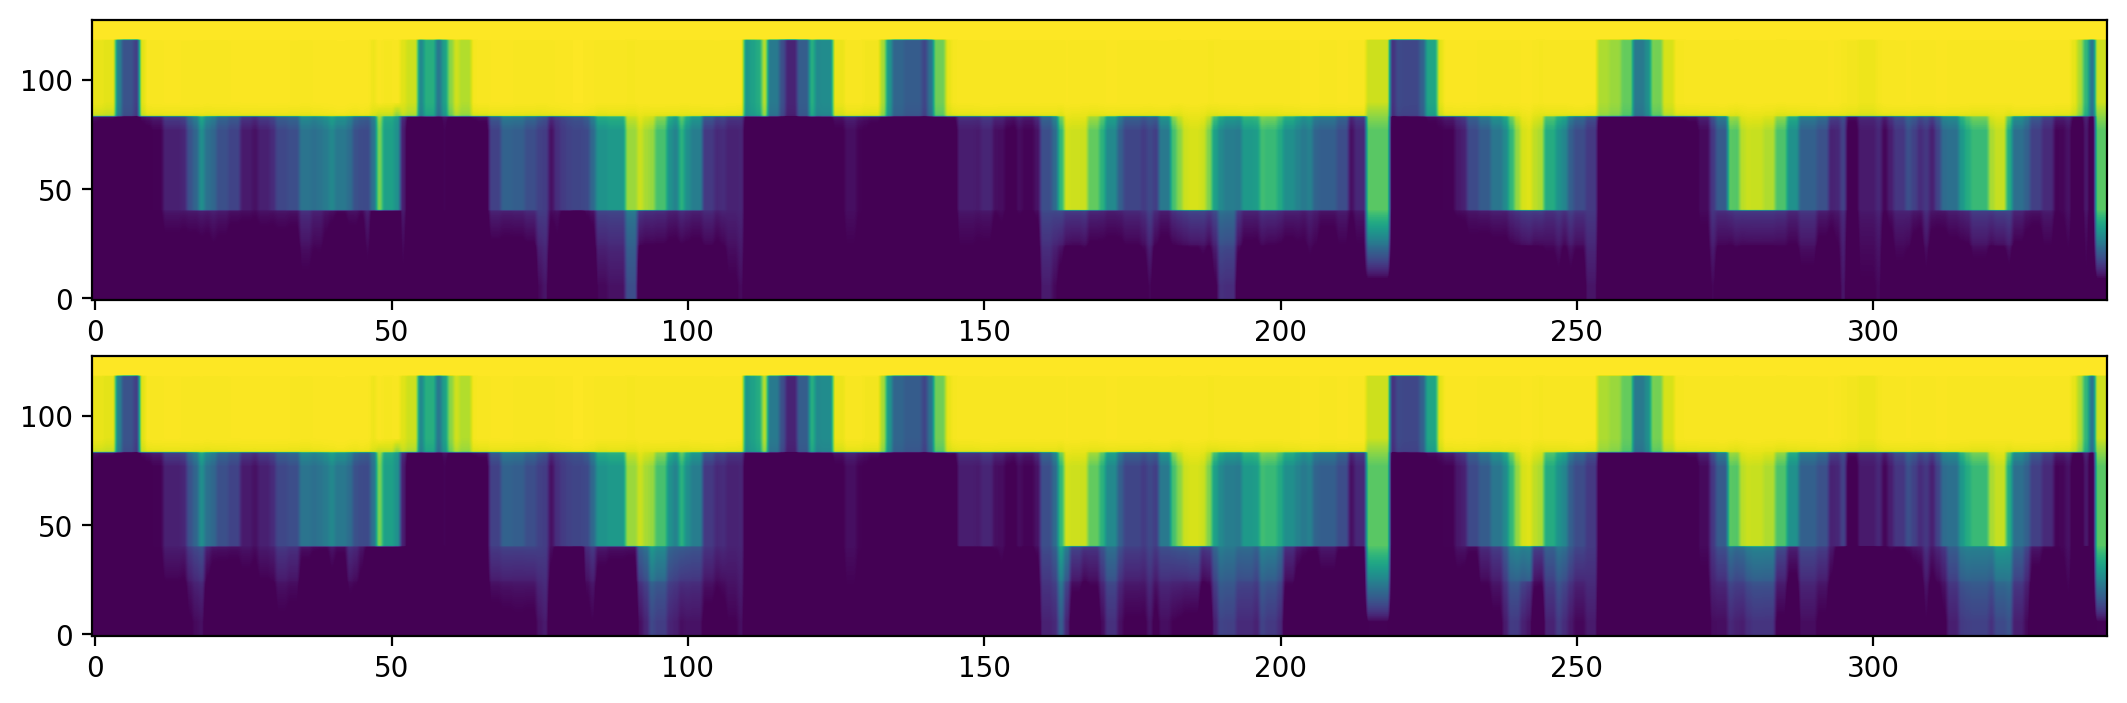

In [712]:
plt.figure(figsize=(13, 4))

plt.subplot(2, 1, 1)
plt.imshow(f_norm[t_indices], aspect='auto', origin='lower', vmax=1., vmin=0.1)

plt.subplot(2, 1, 2)
plt.imshow(f_norm[b_indices], aspect='auto', origin='lower', vmax=1., vmin=0.1)

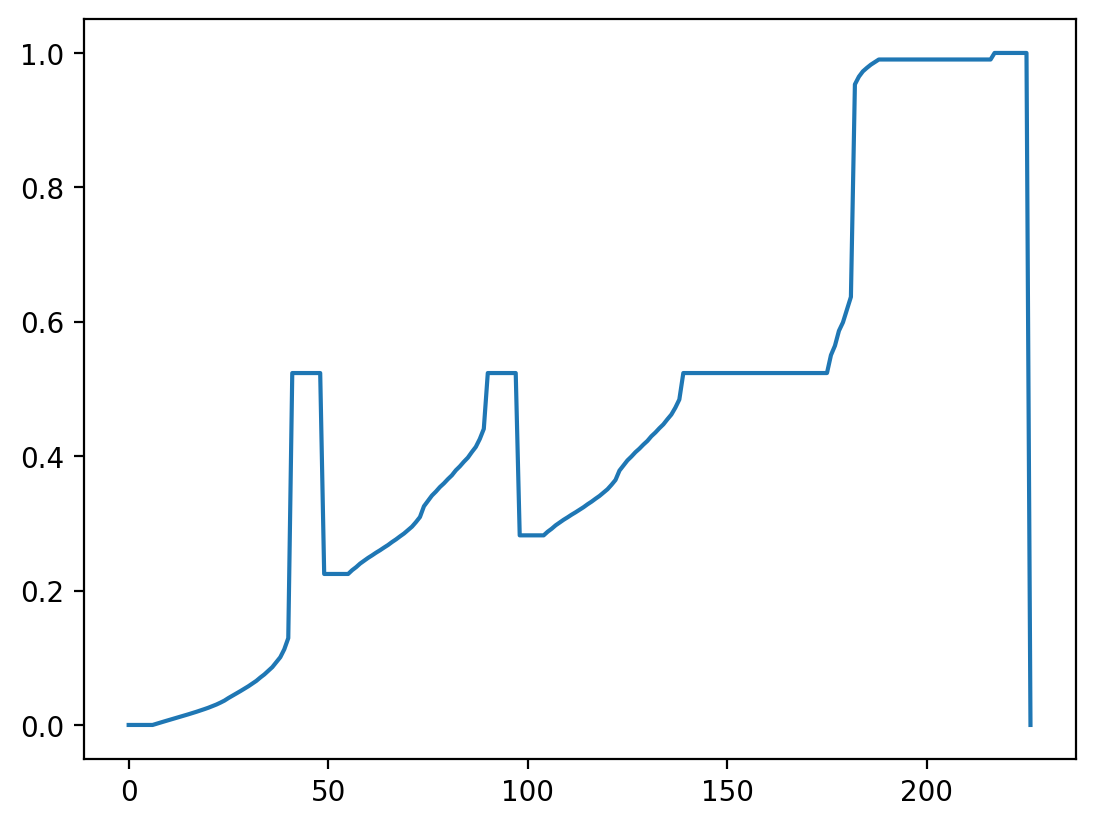

In [713]:
plt.plot(f_norm[:,190])